
Congrats....again! Based off the amazing work you did on the classification model, you've been promoted to chief of all data scientists in Hollywood, your a total celebrity....among data scientists :).  

Your boss, head of the studio, has now asked you to build a model to predict gross revenue in order to help them decide which movies to invest in.

Once again, you would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so...you leverage work you've done in the past to get the job done....you're a data scientist after all! 

In [1]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split,RepeatedKFold,GridSearchCV
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor, export_graphviz 
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import get_scorer_names

In [2]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("../data/movie_metadata.csv")

## 2 Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed. 3 Check for missing variables and correct as needed.

In [3]:
def data_cleaning(df, drop_col):
    df.drop(columns=drop_col, inplace=True, errors="ignore")
    object_cols=df.select_dtypes(include=['object']).columns
    for col in object_cols:
        df[col]=df[col].astype('category')
    df = df.dropna()
    
    return df
movie_metadata = data_cleaning(movie_metadata, ['plot_keywords','movie_imdb_link','actor_2_name','actor_3_name','genres'])
movie_titles = movie_metadata["movie_title"]
movie_metadata = movie_metadata.drop(columns=["movie_title"])
encoder = OneHotEncoder(sparse_output=False)

In [4]:
#import the encoders
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

## encode directors
dir_val=movie_metadata['director_name'].value_counts().nlargest(10).index

#print(dir_val)

movie_metadata['director_name']=movie_metadata['director_name'].apply(
    lambda x: 'Famous' if x in dir_val else 'Other')

#print(movie_metadata['director_name'].value_counts())

#one hot encode
dir_encoded = encoder.fit_transform(movie_metadata[["director_name"]])
dir_1h = pd.DataFrame(
    dir_encoded,
    columns=encoder.get_feature_names_out(['director_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['director_name']), dir_1h], axis=1)

#print(movie_metadata["director_name"].value_counts())

## encode title_year
movie_metadata["title_year"] = movie_metadata["title_year"].apply(
    lambda x: "old" if x < 2000 else "new" if x >= 2010 else "middle"
)

title_encoded=encoder.fit_transform(movie_metadata[["title_year"]])
title_1h = pd.DataFrame(
    title_encoded,
    columns=encoder.get_feature_names_out(['title_year']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['title_year']), title_1h], axis=1)

## encode first actor
act_10 = list(movie_metadata['actor_1_name'].value_counts().nlargest(10).index)

#print(act_10)

# Create a new column so you can compare after
movie_metadata['actor_1_name'] = movie_metadata['actor_1_name'].apply(
    lambda x: 'Famous' if x in act_10 else 'Other'
)

#print(movie_metadata['actor_1_name'].value_counts())

act_encoded = encoder.fit_transform(movie_metadata[["actor_1_name"]])
act_1h = pd.DataFrame(
    act_encoded,
    columns=encoder.get_feature_names_out(['actor_1_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['actor_1_name']), act_1h], axis=1)
#print(movie_metadata['actor_1_name'])

# encode content rating
#print(movie_metadata['content_rating'].value_counts())
movie_metadata['content_rating']=movie_metadata['content_rating'].apply(
    lambda x: 'PG-13' if x == 'PG-13' else 'R' if x == 'R' else 'Other')

#print(movie_metadata['content_rating'].value_counts())

cont_encoded = encoder.fit_transform(movie_metadata[["content_rating"]])
cont_1h = pd.DataFrame(
    cont_encoded,
    columns=encoder.get_feature_names_out(['content_rating']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['content_rating']), cont_1h], axis=1)

# encode country
count10=movie_metadata['country'].value_counts().nlargest(10)
#print(count10)

movie_metadata['country']=movie_metadata['country'].apply(
    lambda x: 'Big Country Producer' if x in count10 else 'Other'
)
#print(movie_metadata['country'].value_counts())

count_encoded = encoder.fit_transform(movie_metadata[["country"]])
count_1h = pd.DataFrame(
    count_encoded,
    columns=encoder.get_feature_names_out(['country']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['country']), count_1h], axis=1)
#print(movie_metadata['actor_1_name'])

# encode language
lang10=movie_metadata['language'].value_counts().nlargest(10)
#print(lang10)

movie_metadata['language']=movie_metadata['language'].apply(
    lambda x: 'English' if x == 'English' else 'French' if x == 'French' else 'Other'
)
#print(movie_metadata['language'].value_counts())

#movie_metadata[['language']]=OneHotEncoder().fit_transform(movie_metadata[['language']])
#print(movie_metadata['language'].value_counts())

language_encoded = encoder.fit_transform(movie_metadata[['language']])

language_1h = pd.DataFrame(
    language_encoded,
    columns=encoder.get_feature_names_out(['language']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['language']), language_1h], axis=1)

# encode color
#print(movie_metadata['color'].value_counts())
movie_metadata['color']=movie_metadata['color'].apply(
    lambda x: 'Color' if x == 'Color' else 'Black and White')

#movie_metadata[['color']]=OneHotEncoder().fit_transform(movie_metadata[['color']])
#print(movie_metadata['color'].value_counts())

color_encoded = encoder.fit_transform(movie_metadata[['color']])

color_1h = pd.DataFrame(
    color_encoded,
    columns=encoder.get_feature_names_out(['color']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['color']), color_1h], axis=1)

# Categorize imdb_score into three classes
movie_metadata["imdb_score"] = movie_metadata["imdb_score"].apply(
    lambda x: "high" if x >= 8.0 else "average" if x > 6.0 else "low"
)

#print(movie_metadata["imdb_score"].value_counts())

movie_metadata["imdb_score"] = OrdinalEncoder().fit_transform(movie_metadata[['imdb_score']])

#print(movie_metadata["imdb_score"].value_counts())

## 4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step. 5 Determine the variance of the target variable, is it normally distributed? If not, you may want to transform the target variable. Why might this be important?

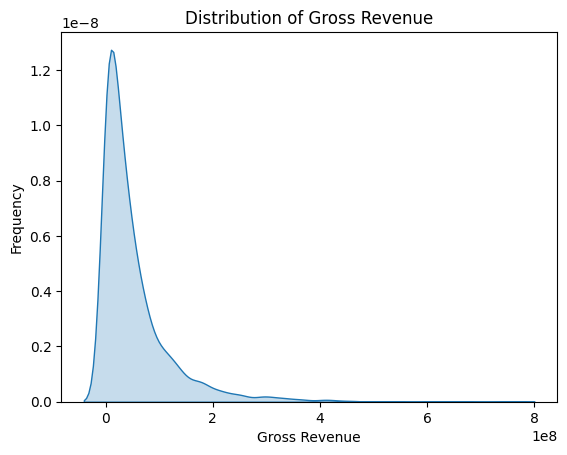

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(movie_metadata, x ='gross', fill=True, common_norm=False)
plt.title('Distribution of Gross Revenue')
plt.xlabel('Gross Revenue')
plt.ylabel('Frequency')
plt.show()

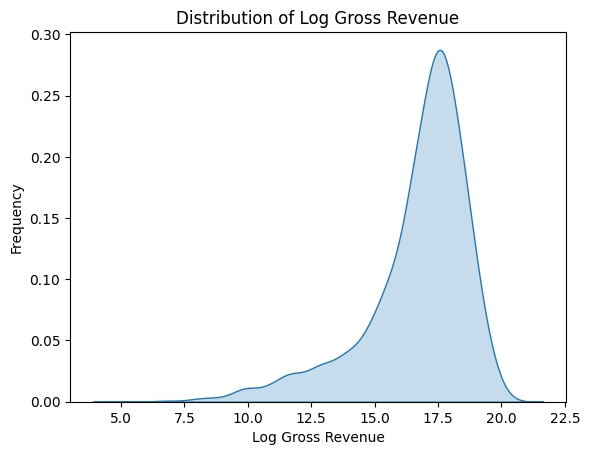

In [6]:
movie_metadata['gross'] = np.log(movie_metadata['gross'])
sns.kdeplot(movie_metadata, x ='gross', fill=True, common_norm=False)
plt.title('Distribution of Log Gross Revenue')
plt.xlabel('Log Gross Revenue')
plt.ylabel('Frequency')
plt.show()

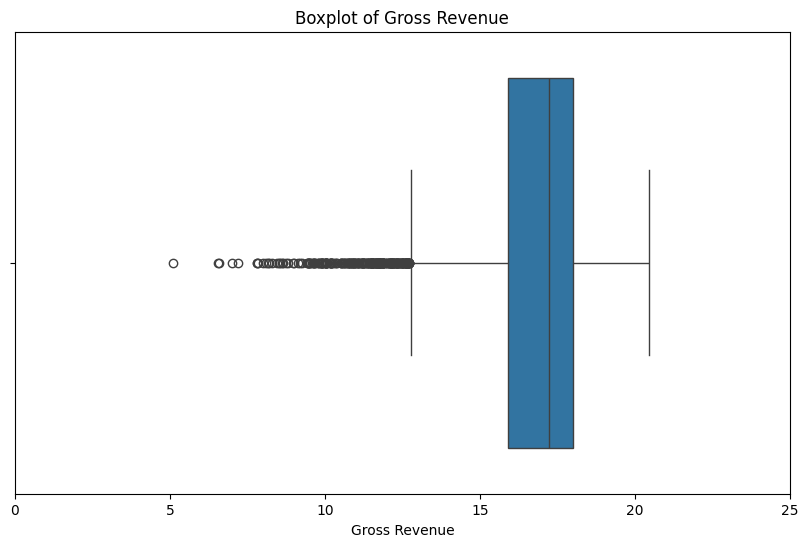

      num_critic_for_reviews  duration  director_facebook_likes  \
327                    136.0     146.0                    611.0   
382                    142.0     114.0                  12000.0   
392                     47.0     110.0                     96.0   
700                     68.0     103.0                     10.0   
800                    189.0     118.0                    167.0   
...                      ...       ...                      ...   
4998                    21.0      90.0                      4.0   
5004                     3.0      78.0                      6.0   
5025                    73.0     108.0                      0.0   
5026                    81.0     110.0                    107.0   
5042                    43.0      90.0                     16.0   

      actor_3_facebook_likes  actor_1_facebook_likes      gross  \
327                     28.0                 23000.0   9.128371   
382                    307.0                 11000.0  10.1988

In [7]:
# Step 2: Calculate IQR
Q1 = movie_metadata['gross'].quantile(0.25)
Q3 = movie_metadata['gross'].quantile(0.75)
IQR = Q3 - Q1

# Step 3: Define bounds for non-outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# check for outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=movie_metadata['gross'])
plt.title('Boxplot of Gross Revenue')
plt.xlabel('Gross Revenue')
plt.xlim(0, 25)
plt.show()

outliers = movie_metadata[(movie_metadata['gross'] < lower_bound) | (movie_metadata['gross'] > upper_bound)]
print(outliers)

# Filter the movie_metadata DataFrame to remove outliers
movie_metadata = movie_metadata[(movie_metadata['gross'] > lower_bound) & (movie_metadata['gross'] <= upper_bound)]

# Update movie_titles to exclude the indices of the removed outliers
movie_titles = movie_titles[movie_titles.index.isin(movie_metadata.index)]

## 6 Split your data into test, tune, and train. (80/10/10)

In [8]:
X = movie_metadata.drop('gross', axis=1)
y = movie_metadata['gross']

In [9]:
X_train, X_test, y_train, y_test, title_train, title_test= train_test_split(X, y, movie_titles, train_size=0.80, random_state=21)
X_tune, X_test, y_tune, y_test, title_tune, title_test = train_test_split(X_test,y_test, title_test, train_size = 0.50, random_state=49)

## 7 Create the kfold object for cross validation.

In [10]:
kf = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)
param={
    "max_depth" : [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    #"splitter":["best","random"],
    #"min_samples_leaf":[1,2,3,4,5,6,7,8,9,10],
    #"min_weight_fraction_leaf":[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    #"max_features":["auto","log2","sqrt",None],
    #"max_leaf_nodes":[None,10,20,30,40,50,60,70,80,90] 
    #'min_impurity_decrease':[0.00005,0.0001,0.0002,0.0005,0.001,0.0015,0.002,0.005,0.01],
    #'ccp_alpha':[.001,.01,.1]
        }

## 8 Create the scoring metric (several measures) you will use to evaluate your model and the max depth hyperparameter.

In [11]:
print(get_scorer_names())
scoring = ['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error']

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

## 9 Build the regression tree object. 

In [12]:
reg=DecisionTreeRegressor(random_state=30)
search = GridSearchCV(reg, param, scoring=scoring, n_jobs=-1, cv=kf,refit='r2')

## 10 Fit the model to the training data.

In [13]:
model = search.fit(X_train, y_train)

In [14]:
# best hyperparameters
print("Best Hyperparameters: ", model.best_params_)
# best score
print("Best Score: ", model.best_score_)

Best Hyperparameters:  {'max_depth': 6}
Best Score:  0.497645236675768


## 11 Explore the results of the model. Print the output of the grid search. What is the best parameter and score?

In [15]:
# Print the results of the grid search
print(pd.DataFrame(model.cv_results_))

best=model.best_estimator_
print(best)

# Print the best hyperparameters
print(model.best_params_)

# Print the best score
print(model.best_score_)

    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        0.008049      0.002810         0.003501        0.002026   
1        0.013863      0.004863         0.004479        0.002359   
2        0.017689      0.004308         0.004410        0.002403   
3        0.024008      0.008949         0.004594        0.003033   
4        0.024941      0.006859         0.004351        0.002689   
5        0.027416      0.004510         0.003722        0.002117   
6        0.032065      0.007408         0.003521        0.001698   
7        0.036842      0.006927         0.003577        0.001420   
8        0.037928      0.004164         0.003764        0.002370   
9        0.042951      0.005936         0.003755        0.001811   
10       0.050027      0.007684         0.004137        0.003062   
11       0.054094      0.009970         0.004084        0.002540   
12       0.056450      0.014455         0.004183        0.002901   
13       0.078414      0.030981         0.007506

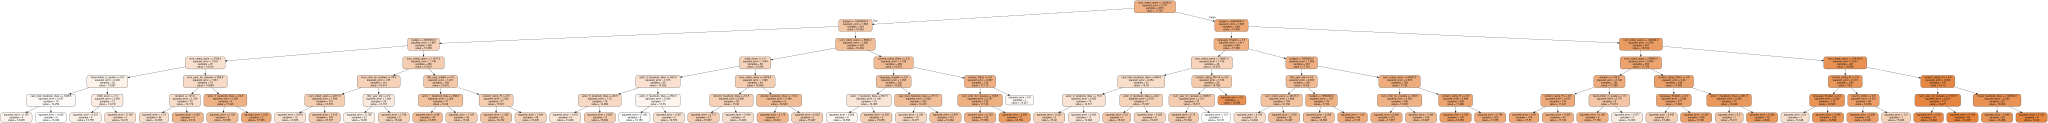

In [16]:
import graphviz

dot_data = export_graphviz(best, out_file=None,
               feature_names=X.columns,  # feature names from dataset
               filled=True, 
               rounded=True) 
               
graph = graphviz.Source(dot_data)
graph

## 12 Which variables appear to be contributing the most (variable importance)

In [17]:
varimp=pd.DataFrame(best.feature_importances_,index = X_train.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

                              importance
num_voted_users                 0.567038
budget                          0.241898
language_English                0.055916
num_critic_for_reviews          0.025035
content_rating_Other            0.018619
content_rating_R                0.018169
title_year_old                  0.011958
duration                        0.008306
num_user_for_reviews            0.007754
actor_1_facebook_likes          0.007681
cast_total_facebook_likes       0.006431
country_Other                   0.005570
facenumber_in_poster            0.005559
imdb_score                      0.004582
title_year_middle               0.004126
actor_2_facebook_likes          0.004006
actor_3_facebook_likes          0.002428
content_rating_PG-13            0.002252
director_facebook_likes         0.002056
movie_facebook_likes            0.000614
country_Big Country Producer    0.000000
language_Other                  0.000000
language_French                 0.000000
color_Black and 

## 13 Create a model object using the best model hyperparameter value from the trained regression tree.

In [18]:
best=model.best_estimator_

## 14 Using the best model predict on the tune data and print out the results.

In [19]:
y_pred = best.predict(X_tune)
print(y_pred)

[16.46210818 17.45539467 18.59227969 17.8313393  17.45539467 15.7373765
 16.46210818 18.59227969 16.66699574 17.05286837 15.7373765  18.49829353
 15.7373765  16.46210818 17.05286837 19.33007603 17.12570174 17.3074749
 17.3074749  15.20749823 17.56997769 17.3074749  16.07183018 17.8313393
 16.46210818 17.3074749  16.57252926 15.7373765  17.3074749  17.8313393
 17.8313393  17.3074749  15.66930742 16.46210818 16.84085996 18.38049353
 18.05316711 17.05286837 16.66699574 15.74193749 16.46210818 17.05286837
 18.59227969 18.59227969 16.46210818 15.7373765  16.66699574 16.46210818
 15.7373765  16.46210818 16.38656238 17.3074749  17.56997769 17.45539467
 16.46210818 17.45539467 17.3074749  14.84356442 17.8313393  17.3074749
 15.56711171 17.8313393  16.46210818 17.8313393  18.05316711 18.38049353
 16.46210818 17.3074749  16.66699574 18.38049353 18.15849112 16.46210818
 17.8313393  17.05286837 19.08176566 17.8313393  16.66699574 17.45539467
 17.37007615 16.46210818 15.90089565 18.09211303 16.4621

## 15 How does the model perform on the tune data as compared to the training data?

In [20]:
print(model.score(X_tune, y_tune))
print(model.score(X_train, y_train))

0.5137000485919418
0.6544755229863597


The model performs better on the training data because the model is trained on the training data.

## 16 What five movies are predicted to have the lowest gross revenue from the tune set?

In [21]:
df_tune = pd.DataFrame({'Movie_title':title_tune, 'Gross':y_pred})
top_movie = df_tune.sort_values(by="Gross", ascending=False).head(5)
print(top_movie)

                                            Movie_title      Gross
270   The Lord of the Rings: The Fellowship of the R...  19.497226
160                                          Star Trek   19.497226
115                Harry Potter and the Goblet of Fire   19.497226
2262                                          Twilight   19.497226
128                                 Mad Max: Fury Road   19.330076


## 17 As a data scientist you are always looking to improve your results. What are some ideas you have to improve the model? Have you ask...WHAT IF?!

1. What if I used some other scoring metrics?
2. What if I ordinal encoded the categorical variables?

## 18 Experiment using your what if ideas (two is fine). Did the model improve? If so, how much? If not, what did you learn? (You don't need to include all the "what if" code just speak to what you tried and what you learned).

Q1

In [22]:
kf = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)
param={
    "max_depth" : [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    #"splitter":["best","random"],
    #"min_samples_leaf":[1,2,3,4,5,6,7,8,9,10],
    #"min_weight_fraction_leaf":[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    #"max_features":["auto","log2","sqrt",None],
    "max_leaf_nodes":[None,10,20,30,40,50,60,70,80,90] 
    #'min_impurity_decrease':[0.00005,0.0001,0.0002,0.0005,0.001,0.0015,0.002,0.005,0.01],
    #'ccp_alpha':[.001,.01,.1]
        }

In [23]:
model2 = GridSearchCV(reg, param, scoring=scoring, n_jobs=-1, cv=kf,refit='r2')
model2.fit(X_train, y_train)
best2=model2.best_estimator_
print(best2.score(X_test, y_test))


0.5604772355210863


Changing the parameter (adding max_leaf_nodes) makes the score pretty decent, even slightly better than the one without the max_leaf_nodes.

Q2

In [24]:
movie_metadata3=pd.read_csv("../data/movie_metadata.csv")
movie_metadata3=movie_metadata3.dropna()
cat = movie_metadata3.select_dtypes(object).columns.tolist()
movie_metadata3[cat]=movie_metadata3[cat].astype('category')
#create the target variable
movie_metadata3['imdb_score'] = movie_metadata3['imdb_score'].apply(
    lambda x: 'high' if x >= 7.5 else 'average'
)
movie_metadata3['imdb_score']=OrdinalEncoder().fit_transform(movie_metadata3[['imdb_score']])
#print(movie_metadata3['imdb_score'])

# encode directors
dir_val=movie_metadata3['director_name'].value_counts().nlargest(10).index
#print(dir_val)
movie_metadata3['director_name']=movie_metadata3['director_name'].apply(
    lambda x: 'Famous' if x in dir_val else 'Other')
#print(movie_metadata3['director_name'].value_counts())
movie_metadata3['director_name']=OrdinalEncoder().fit_transform(movie_metadata3[['director_name']])
#print(movie_metadata3['director_name'])

#encode title_year
movie_metadata3["title_year"] = movie_metadata3["title_year"].apply(
    lambda x: "old" if x < 2000 else "new" if x >= 2010 else "middle"
)
movie_metadata3["title_year"]=OrdinalEncoder().fit_transform(movie_metadata3[['title_year']])
#print(movie_metadata3['title_year'])

#encode first actor
act_10 = movie_metadata3['actor_1_name'].value_counts().nlargest(10).index
#print(act_10)
movie_metadata3['actor_1_name'] = movie_metadata3['actor_1_name'].apply(
    lambda x: 'Famous' if x in act_10 else 'Other'
)
movie_metadata3['actor_1_name']=OrdinalEncoder().fit_transform(movie_metadata3[['actor_1_name']])

#encode country
count10=movie_metadata3['country'].value_counts().nlargest(10)
#print(count10)
movie_metadata3['country']=movie_metadata3['country'].apply(
    lambda x: 'Big Country Producer' if x in count10 else 'Other'
)
#print(movie_metadata3['country'].value_counts())
movie_metadata3['country']=OrdinalEncoder().fit_transform(movie_metadata3[['country']])
#print(movie_metadata3['country'])

#encode content rating
#print(movie_metadata3['content_rating'].value_counts())
movie_metadata3['content_rating']=movie_metadata3['content_rating'].apply(
    lambda x: 'PG-13' if x == 'PG-13' else 'R' if x == 'R' else 'Other')
#print(movie_metadata3['content_rating'].value_counts())
movie_metadata3['content_rating']=OrdinalEncoder().fit_transform(movie_metadata3[['content_rating']])
#print(movie_metadata3['content_rating'])

#encode language
lang10=movie_metadata3['language'].value_counts().nlargest(10)
#print(lang10)
movie_metadata3['language']=movie_metadata3['language'].apply(
    lambda x: 'English' if x == 'English' else 'French' if x == 'French' else 'Other'
)
#print(movie_metadata3['language'].value_counts())
movie_metadata3['language']=OrdinalEncoder().fit_transform(movie_metadata3[['language']])
#print(movie_metadata3['language'])

#encode color
#print(movie_metadata3['color'].value_counts())
movie_metadata3['color']=movie_metadata3['color'].apply(
    lambda x: 'Color' if x == 'Color' else 'Black and White')
#print(movie_metadata3['color'].value_counts())
movie_metadata3['color']=OrdinalEncoder().fit_transform(movie_metadata3[['color']])
#print(movie_metadata3['color'])

Q1 = movie_metadata3['gross'].quantile(0.25)
Q3 = movie_metadata3['gross'].quantile(0.75)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

movie_metadata3 = movie_metadata3[(movie_metadata3['gross'] >= lower_bound) & (movie_metadata3['gross'] <= upper_bound)]

#drop irrelevant columns
movie_metadata3=movie_metadata3.drop(['movie_title','plot_keywords','movie_imdb_link','actor_2_name','actor_3_name','genres'],axis=1)

#train-tune-test split
movie_metadata3['gross']=np.log(movie_metadata3['gross'])
X3 = movie_metadata3.drop(columns=['gross'])
y3 = movie_metadata3['gross']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, train_size=0.70, random_state=21)
X3_tune, X3_test, y3_tune, y3_test = train_test_split(X3_test, y3_test, train_size=0.50, random_state=49)

#create scoring metrics
scoring = ['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error']
param={"max_depth" : [1,2,3,4,5]}
#create the decision tree regressor
reg=DecisionTreeRegressor(random_state=30)
#Set up search for best decision tree classifier estimator across all of our folds based on roc_auc
search = GridSearchCV(reg, param, scoring=scoring, n_jobs=-1, cv=kf,refit='r2')
#execute search on our training data
model3 = search.fit(X3_train, y3_train)
#Retrieve the best estimator out of all parameters passed
best3 = model3.best_estimator_
print(best3)
print(best3.score(X3_test, y3_test))

DecisionTreeRegressor(max_depth=3, random_state=30)
0.07524460622070661


Using OrdinalEncoding greatly decreases the score of the model, because the categorical variables should not be processed in an ordinal way.

## 19 Use the best model to predict on the test data and print out the evaluation results.

In [25]:
y_pred = best.predict(X_test)
print(y_pred)

[17.05286837 15.56711171 17.45539467 17.12570174 15.7373765  16.38656238
 15.2453305  15.48553729 17.8313393  15.7373765  14.65912028 18.09211303
 17.56997769 17.05286837 17.3074749  15.2453305  18.38049353 14.65912028
 16.46210818 16.46210818 16.46210818 17.56997769 16.07183018 17.8313393
 17.45539467 15.56711171 18.09211303 14.65912028 14.66279769 17.56997769
 17.8313393  16.46210818 18.59227969 17.45539467 17.56997769 17.45539467
 17.05286837 16.46210818 18.09211303 15.7373765  18.05316711 18.38049353
 17.8313393  15.7373765  16.46210818 16.46210818 16.66699574 16.66699574
 17.37007615 16.46210818 17.56997769 17.12570174 14.52486104 15.7373765
 16.66699574 13.84950776 17.56997769 17.45539467 16.66699574 17.8313393
 15.20749823 18.05316711 17.3074749  17.37007615 16.38656238 19.08176566
 16.66699574 16.66699574 17.8313393  17.37007615 16.57252926 18.38049353
 18.38049353 16.57252926 16.46210818 18.49829353 17.45539467 16.57252926
 17.3074749  16.46210818 17.45539467 14.65912028 18.49

## 20 Does the model perform well on the test data when compared to the training and tune data? Why or why not?

In [26]:
print("The score on the test data is: ",best.score(X_test, y_test))
print("The score on the train data is: ",best.score(X_train, y_train))
print("The score on the tune data is : ",best.score(X_tune, y_tune))

The score on the test data is:  0.5545593129322158
The score on the train data is:  0.6544755229863597
The score on the tune data is :  0.5137000485919418


## 21 Where are the errors occurring in your predictions? Are they systematic or random? In either case, what are the implications of this?

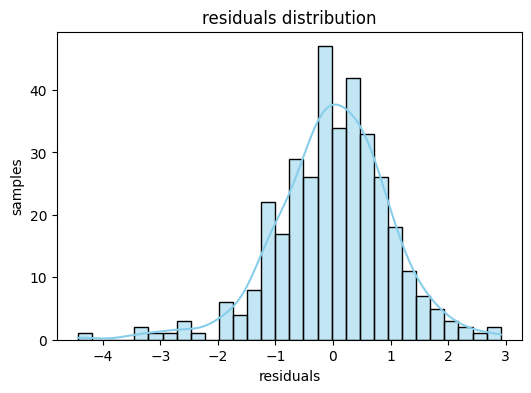

In [27]:
y_test_pred = best2.predict(X_test)
residuals = y_test - y_test_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, bins=30, color='skyblue')
plt.title("residuals distribution")
plt.xlabel("residuals")
plt.ylabel("samples")
plt.show()

The histogram of the errors shows that the errors are systematic, because the errors are not randomly distributed. The errors are concentrated in a certain range of values, which means that the model is not able to predict those values correctly. This could be due to the fact that the model is not able to capture the underlying patterns in the data, or it could be due to the fact that there are some outliers in the data that are affecting the model's performance.

## 22 Summarize what you learned along the way and make recommendations on how this could be used moving forward, being careful not to over promise.

1. The regression decision tree model is not so different from the classification model in terms of variable collapsing and encoding. The only difference worth noticing is that in a regression model one needs to examine the distribution and variance of the target variable, to remove outliers and transform the target variable if needed.
2. Unlike the classification model, which does not react very dramatically to the change in encoding method (OneHot and Ordinal), the regression model is very sensitive to the encoding method. The OrdinalEncoding method is not appropriate for the regression model, because it assumes that the categorical variables have an ordinal relationship, which is not true in this case.
